In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

from datasets import load_dataset
from transformers import BertTokenizer, BertModel, ViTModel, ViTImageProcessor

import numpy as np
from PIL import Image
from tqdm import tqdm
import random

# Data Loading — MSCOCO (Karpathy Split)

Using `jxie/coco_captions` which provides the standard Karpathy split of MSCOCO with embedded images.
Each row is one image–caption pair. Images have 5 captions each.

- **Train**: ~567K pairs (~113K images × 5 captions)
- **Validation**: 25K pairs (5K images × 5 captions)
- **Test**: 25K pairs (5K images × 5 captions)

> ⚠️ First download is ~21 GB (images are embedded in the dataset). Subsequent loads use a local cache.

In [ ]:
dataset = load_dataset("jxie/coco_captions")

train_data = dataset["train"]
val_data = dataset["validation"]
test_data = dataset["test"]

print(f"Train: {len(train_data):,} | Val: {len(val_data):,} | Test: {len(test_data):,}")
print(f"Columns: {train_data.column_names}")
print(f"\nSample entries:")
for i in range(3):
    row = train_data[i]
    print(f"  cocoid={row['cocoid']}, caption={row['caption'][:80]}...")

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=333x500 at 0x1A21389CED0>, 'caption': 'Two young guys with shaggy hair look at their hands while hanging out in the yard.', 'split': 'train', 'img_id': '0', 'filename': '1000092795.jpg'}
{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=333x500 at 0x1A21394A950>, 'caption': 'Two men in green shirts are standing in a yard.', 'split': 'train', 'img_id': '0', 'filename': '1000092795.jpg'}
{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=333x500 at 0x1A21394AA50>, 'caption': 'Two friends enjoy time spent together.', 'split': 'train', 'img_id': '0', 'filename': '1000092795.jpg'}
{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=500x374 at 0x1A21394AA50>, 'caption': 'Workers look down from up above on a piece of equipment.', 'split': 'train', 'img_id': '1', 'filename': '10002456.jpg'}
{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=500x374 at 0x1A21394ADD0>, 'captio

In [ ]:
print(f"Test set size: {len(test_data)}")
print(f"Unique images: {len(set(test_data['cocoid']))}")
print(f"Captions per image: {len(test_data) / len(set(test_data['cocoid'])):.0f}")

Test set size: 5000
Unique images: 1000
Captions per image: 5


In [3]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
image_processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224")

# The Model — Enhanced Cross-Attention Re-Ranker

**Stage 1** (unchanged): ViT image encoder + BERT text encoder with projection heads for contrastive retrieval.

**Stage 2** (enhanced): Bidirectional, multi-layer, multi-head cross-attention re-ranker.

### Enhancements over baseline Stage 2:
| Aspect | Baseline | Enhanced |
|--------|----------|----------|
| Attention heads | 1 | 12 |
| Direction | Text→Image only | Bidirectional (Text↔Image) |
| Layers | 1 | 3 stacked layers |
| Normalization | None | Pre-LayerNorm + residual connections |
| Feed-forward | None | GELU FFN per layer |
| Pooling | Mean pooling | Learned attention-weighted pooling |
| Fusion | Direct → MLP | [concat; product; difference] → deep MLP |
| Regularization | None | Dropout throughout |

### Why this helps word–patch alignment:
- **Multi-head attention** allows different heads to specialize — one head may attend to spatial regions (e.g. "dog" → bottom-left patches), another to texture/color.
- **Bidirectional** cross-attention lets image patches also query text tokens, creating a richer mutual representation.
- **Stacked layers** iteratively refine the alignment: early layers capture coarse correspondences, later layers resolve fine-grained details.
- **Learned pooling** weights informative tokens more heavily than uninformative ones (e.g. articles, padding).

In [ ]:
class MultiHeadCrossAttentionLayer(nn.Module):
    """Single cross-attention layer: multi-head attention + FFN, with pre-norm residual connections."""

    def __init__(self, dim, num_heads=12, dropout=0.1):
        super().__init__()
        self.norm_q = nn.LayerNorm(dim)
        self.norm_kv = nn.LayerNorm(dim)
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=dim, num_heads=num_heads, dropout=dropout, batch_first=True
        )
        self.norm_ffn = nn.LayerNorm(dim)
        self.ffn = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim * 4, dim),
            nn.Dropout(dropout),
        )

    def forward(self, query, key_value):
        # Pre-norm cross-attention with residual
        q_norm = self.norm_q(query)
        kv_norm = self.norm_kv(key_value)
        attn_out, attn_weights = self.cross_attn(q_norm, kv_norm, kv_norm)
        query = query + attn_out

        # Pre-norm FFN with residual
        query = query + self.ffn(self.norm_ffn(query))
        return query, attn_weights


class EnhancedCrossAttentionReranker(nn.Module):
    """
    Bidirectional, multi-layer, multi-head cross-attention re-ranker.

    Architecture:
      1. N stacked bidirectional cross-attention blocks
         - Text tokens attend to image tokens (Text->Image)
         - Image tokens attend to text tokens (Image->Text)
         - Both streams evolve iteratively through layers
      2. Learned attention-weighted pooling (not simple mean)
      3. Rich fusion: [t2i; i2t; t2i*i2t; |t2i-i2t|]
      4. Deep classification head with LayerNorm + dropout
    """

    def __init__(self, dim=768, num_heads=12, num_layers=3, dropout=0.1):
        super().__init__()
        self.t2i_layers = nn.ModuleList([
            MultiHeadCrossAttentionLayer(dim, num_heads, dropout)
            for _ in range(num_layers)
        ])
        self.i2t_layers = nn.ModuleList([
            MultiHeadCrossAttentionLayer(dim, num_heads, dropout)
            for _ in range(num_layers)
        ])

        self.t2i_final_norm = nn.LayerNorm(dim)
        self.i2t_final_norm = nn.LayerNorm(dim)

        # Learned attention-weighted pooling
        self.t2i_pool = nn.Linear(dim, 1)
        self.i2t_pool = nn.Linear(dim, 1)

        # Classifier: processes [t2i; i2t; t2i*i2t; |t2i-i2t|]
        self.match_head = nn.Sequential(
            nn.Linear(dim * 4, dim),
            nn.LayerNorm(dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim // 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim // 4, 1),
        )

    def attn_pool(self, x, pool_layer):
        """Learned attention-weighted pooling over the sequence dimension."""
        weights = F.softmax(pool_layer(x).squeeze(-1), dim=-1)  # (B, seq_len)
        return torch.bmm(weights.unsqueeze(1), x).squeeze(1)    # (B, dim)

    def forward(self, text_tokens, image_tokens):
        """
        Args:
            text_tokens:  (B, T, D) -- BERT encoder outputs
            image_tokens: (B, P, D) -- ViT encoder outputs
        Returns:
            logits: (B,) -- match score logits
        """
        t2i = text_tokens
        i2t = image_tokens

        for t2i_layer, i2t_layer in zip(self.t2i_layers, self.i2t_layers):
            new_t2i, _ = t2i_layer(t2i, i2t)   # text queries -> image context
            new_i2t, _ = i2t_layer(i2t, t2i)   # image queries -> text context
            t2i = new_t2i
            i2t = new_i2t

        t2i = self.t2i_final_norm(t2i)
        i2t = self.i2t_final_norm(i2t)

        t2i_pooled = self.attn_pool(t2i, self.t2i_pool)  # (B, D)
        i2t_pooled = self.attn_pool(i2t, self.i2t_pool)  # (B, D)

        fused = torch.cat([
            t2i_pooled,
            i2t_pooled,
            t2i_pooled * i2t_pooled,              # interaction
            torch.abs(t2i_pooled - i2t_pooled),   # contrast
        ], dim=-1)  # (B, 4*D)

        return self.match_head(fused).squeeze(-1)  # (B,)

In [ ]:
class TwoStageModel(nn.Module):
    def __init__(self, embed_dim=256, reranker_heads=12, reranker_layers=3, reranker_dropout=0.1):
        super().__init__()

        self.text_encoder = BertModel.from_pretrained("bert-base-uncased")
        self.image_encoder = ViTModel.from_pretrained("google/vit-base-patch16-224")

        dim = 768

        # Stage 1: projection heads for contrastive retrieval (unchanged)
        self.image_proj = nn.Linear(dim, embed_dim)
        self.text_proj = nn.Linear(dim, embed_dim)

        # Stage 2: Enhanced cross-attention re-ranker
        self.reranker = EnhancedCrossAttentionReranker(
            dim=dim, num_heads=reranker_heads,
            num_layers=reranker_layers, dropout=reranker_dropout,
        )

        self.temperature = nn.Parameter(torch.tensor(0.07))

    # B = batch size, P = image patches, T = text tokens, D = hidden dim (768)
    def encode_image(self, pixel_values):
        """Encode images -> (embedding for retrieval, token features for re-ranking)."""
        image_out = self.image_encoder(pixel_values=pixel_values).last_hidden_state  # (B, P, D)
        image_emb = F.normalize(self.image_proj(image_out[:, 0]), dim=-1)            # (B, embed_dim)
        return image_emb, image_out

    def encode_text(self, input_ids, attention_mask):
        """Encode text -> (embedding for retrieval, token features for re-ranking)."""
        text_out = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state  # (B, T, D)
        text_emb = F.normalize(self.text_proj(text_out[:, 0]), dim=-1)               # (B, embed_dim)
        return text_emb, text_out

    def compute_itm(self, text_tokens, image_tokens):
        """Stage 2: enhanced cross-attention fusion -> match score."""
        return self.reranker(text_tokens, image_tokens)

    def forward(self, input_ids, attention_mask, pixel_values):
        """Full forward: returns (image_emb, text_emb, itm_logits)."""
        image_emb, image_tokens = self.encode_image(pixel_values)
        text_emb, text_tokens = self.encode_text(input_ids, attention_mask)
        itm_logits = self.compute_itm(text_tokens, image_tokens)
        return image_emb, text_emb, itm_logits

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

model = TwoStageModel().to(device)

# Print parameter counts
total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
reranker_params = sum(p.numel() for p in model.reranker.parameters())
print(f"Total parameters:    {total:,}")
print(f"Trainable:           {trainable:,}")
print(f"Reranker (Stage 2):  {reranker_params:,}")

cuda


Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


# Training

### Key improvements for Stage 2 training:
1. **Hard negative mining** — use Stage 1 similarity to select the hardest in-batch negatives for ITM
2. **Weighted loss** — 70% weight on ITM loss to prioritize Stage 2 learning
3. **Differential learning rates** — lower LR for pretrained encoders, higher for the reranker
4. **Warmup + cosine decay** schedule
5. **Gradient clipping** for stable training
6. **Longer captions** — max 64 tokens (COCO captions are richer than Flickr30k)

In [ ]:
def collate_fn(batch):
    """Collate positive pairs only -- negatives are mined during training."""
    texts = [x["caption"] for x in batch]
    images = [x["image"].convert("RGB") for x in batch]

    text_enc = tokenizer(
        texts, padding="max_length", truncation=True, max_length=64, return_tensors="pt"
    )
    image_enc = image_processor(images=images, return_tensors="pt")

    return {
        "input_ids": text_enc["input_ids"],
        "attention_mask": text_enc["attention_mask"],
        "pixel_values": image_enc["pixel_values"],
    }

In [ ]:
def train(model, batch_size=24, epochs=5, lr_encoder=2e-5, lr_reranker=1e-4):
    train_loader = DataLoader(
        train_data, batch_size=batch_size, shuffle=True,
        collate_fn=collate_fn, num_workers=4, pin_memory=True,
    )
    val_loader = DataLoader(
        val_data, batch_size=batch_size, shuffle=False,
        collate_fn=collate_fn, num_workers=4, pin_memory=True,
    )

    # ── Differential learning rates ──
    encoder_params = (
        list(model.text_encoder.parameters()) +
        list(model.image_encoder.parameters())
    )
    proj_params = (
        list(model.image_proj.parameters()) +
        list(model.text_proj.parameters()) +
        [model.temperature]
    )
    reranker_params = list(model.reranker.parameters())

    optimizer = torch.optim.AdamW([
        {"params": encoder_params, "lr": lr_encoder},
        {"params": proj_params,    "lr": lr_encoder * 2},
        {"params": reranker_params, "lr": lr_reranker},
    ], weight_decay=0.01)

    # ── Warmup + cosine decay ──
    total_steps = len(train_loader) * epochs
    warmup_steps = int(0.1 * total_steps)

    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(warmup_steps, 1)
        progress = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
        return max(0.0, 0.5 * (1 + np.cos(np.pi * progress)))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    itm_criterion = nn.BCEWithLogitsLoss()
    contrastive_weight = 0.3
    itm_weight = 0.7

    for epoch in range(epochs):
        # ─── Training ─────────────────────────────────────────────
        model.train()
        total_loss = 0
        total_cl = 0
        total_itm = 0

        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            pixel_values = batch["pixel_values"].to(device)
            B = input_ids.size(0)

            # Forward through encoders
            image_emb, image_tokens = model.encode_image(pixel_values)
            text_emb, text_tokens = model.encode_text(input_ids, attention_mask)

            # ── Stage 1 loss: contrastive ──
            sim = image_emb @ text_emb.T / model.temperature
            cl_labels = torch.arange(B, device=device)
            loss_i2t = F.cross_entropy(sim, cl_labels)
            loss_t2i = F.cross_entropy(sim.T, cl_labels)
            contrastive_loss = (loss_i2t + loss_t2i) / 2

            # ── Hard negative mining for Stage 2 ──
            with torch.no_grad():
                sim_detach = sim.detach().clone()
                sim_detach.fill_diagonal_(-float('inf'))
                hard_neg_text_idx = sim_detach.argmax(dim=1)   # per image: hardest wrong caption
                hard_neg_img_idx  = sim_detach.argmax(dim=0)   # per caption: hardest wrong image

            # Positive ITM pairs
            pos_logits = model.compute_itm(text_tokens, image_tokens)

            # Hard negative pairs: same image, wrong caption
            neg_logits_1 = model.compute_itm(text_tokens[hard_neg_text_idx], image_tokens)

            # Hard negative pairs: same caption, wrong image
            neg_logits_2 = model.compute_itm(text_tokens, image_tokens[hard_neg_img_idx])

            all_itm_logits = torch.cat([pos_logits, neg_logits_1, neg_logits_2])
            all_itm_labels = torch.cat([
                torch.ones(B, device=device),
                torch.zeros(B, device=device),
                torch.zeros(B, device=device),
            ])
            itm_loss = itm_criterion(all_itm_logits, all_itm_labels)

            # ── Combined loss ──
            loss = contrastive_weight * contrastive_loss + itm_weight * itm_loss

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()

            total_loss += loss.item()
            total_cl += contrastive_loss.item()
            total_itm += itm_loss.item()

        n = len(train_loader)
        print(f"  Train -- Loss: {total_loss/n:.4f}  (CL: {total_cl/n:.4f}, ITM: {total_itm/n:.4f})")

        # ─── Validation ───────────────────────────────────────────
        model.eval()
        val_loss_sum = 0
        correct = 0
        total_samples = 0

        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                pixel_values = batch["pixel_values"].to(device)
                B = input_ids.size(0)

                image_emb, image_tokens = model.encode_image(pixel_values)
                text_emb, text_tokens = model.encode_text(input_ids, attention_mask)

                # Contrastive loss
                sim = image_emb @ text_emb.T / model.temperature
                cl_labels = torch.arange(B, device=device)
                contrastive_loss = (
                    F.cross_entropy(sim, cl_labels) + F.cross_entropy(sim.T, cl_labels)
                ) / 2

                # Hard negatives for validation ITM too
                sim_d = sim.clone()
                sim_d.fill_diagonal_(-float('inf'))
                hard_neg_text = sim_d.argmax(dim=1)
                hard_neg_img  = sim_d.argmax(dim=0)

                pos_logits = model.compute_itm(text_tokens, image_tokens)
                neg_logits_1 = model.compute_itm(text_tokens[hard_neg_text], image_tokens)
                neg_logits_2 = model.compute_itm(text_tokens, image_tokens[hard_neg_img])

                all_logits = torch.cat([pos_logits, neg_logits_1, neg_logits_2])
                all_labels = torch.cat([
                    torch.ones(B, device=device),
                    torch.zeros(B, device=device),
                    torch.zeros(B, device=device),
                ])
                itm_loss = itm_criterion(all_logits, all_labels)
                loss = contrastive_weight * contrastive_loss + itm_weight * itm_loss

                val_loss_sum += loss.item()
                preds = (torch.sigmoid(all_logits) > 0.5).float()
                correct += (preds == all_labels).sum().item()
                total_samples += all_labels.size(0)

        val_n = len(val_loader)
        val_acc = correct / total_samples
        print(f"  Val   -- Loss: {val_loss_sum/val_n:.4f}, ITM Acc: {val_acc:.4f}")

In [ ]:
train(model, batch_size=24, epochs=3, lr_encoder=2e-5, lr_reranker=1e-4)

Epoch 1/1 [Val]: 100%|██████████| 159/159 [00:28<00:00,  5.54it/s]

Epoch 1/1 — Train Loss: 0.6537, Val Loss: 3.6184, Val ITM Acc: 0.6006


# Save/Load Model

In [ ]:
# Save after training:
# torch.save(model.state_dict(), 'weights/advanced_model_COCO_enhanced_rerank.pt')

# Load pretrained weights:
# model.load_state_dict(torch.load('weights/advanced_model_COCO_enhanced_rerank.pt', weights_only=True))

<All keys matched successfully>

# Evaluation: 1to1

In [28]:
def eval_collate_fn(batch):
    """Collate without negatives — just return raw images and captions."""
    texts = [x["caption"] for x in batch]
    images = [x["image"].convert("RGB") for x in batch]
    return texts, images

In [ ]:
def evaluate_image_to_text_1to1(model, data, num_samples=200, top_k=20):
    """Two-stage retrieval: coarse dual-encoder retrieval -> cross-attention re-ranking."""
    subset = data.select(range(min(num_samples, len(data))))
    loader = DataLoader(subset, batch_size=32, shuffle=False, collate_fn=eval_collate_fn)

    all_texts, all_images = [], []
    for texts, images in loader:
        all_texts.extend(texts)
        all_images.extend(images)

    N = len(all_texts)

    # ── Stage 1: Encode everything ──
    print("Stage 1: Computing embeddings...")
    all_image_embs, all_text_embs = [], []
    model.eval()
    bs = 64
    with torch.no_grad():
        for start in range(0, N, bs):
            end = min(start + bs, N)
            image_enc = image_processor(images=all_images[start:end], return_tensors="pt")
            img_emb, _ = model.encode_image(image_enc["pixel_values"].to(device))
            all_image_embs.append(img_emb.cpu())

        for start in range(0, N, bs):
            end = min(start + bs, N)
            text_enc = tokenizer(all_texts[start:end], padding="max_length", truncation=True, max_length=64, return_tensors="pt")
            txt_emb, _ = model.encode_text(text_enc["input_ids"].to(device), text_enc["attention_mask"].to(device))
            all_text_embs.append(txt_emb.cpu())

    all_image_embs = torch.cat(all_image_embs)
    all_text_embs = torch.cat(all_text_embs)
    coarse_sim = all_image_embs @ all_text_embs.T

    # ── Stage 2: Re-rank top-k ──
    print(f"Stage 2: Re-ranking top-{top_k} candidates...")
    score_matrix = torch.full((N, N), -1.0)

    with torch.no_grad():
        for i in tqdm(range(N), desc="Re-ranking"):
            candidates = coarse_sim[i].topk(top_k).indices.tolist()
            img = all_images[i]
            cand_texts = [all_texts[j] for j in candidates]
            image_enc = image_processor(images=[img] * top_k, return_tensors="pt")
            text_enc = tokenizer(cand_texts, padding="max_length", truncation=True, max_length=64, return_tensors="pt")

            itm_logits = model.compute_itm(
                model.encode_text(text_enc["input_ids"].to(device), text_enc["attention_mask"].to(device))[1],
                model.encode_image(image_enc["pixel_values"].to(device))[1],
            )
            itm_scores = torch.sigmoid(itm_logits).cpu()

            for rank, j in enumerate(candidates):
                score_matrix[i][j] = itm_scores[rank]

    def recall_at_k(score_mat, k):
        correct = 0
        for i in range(score_mat.size(0)):
            topk = score_mat[i].topk(k).indices
            if i in topk:
                correct += 1
        return correct / score_mat.size(0)

    print(f"\n=== Stage 1 Only: Coarse Retrieval (N={N}) ===")
    print(f"  Recall@1:  {recall_at_k(coarse_sim, 1):.4f}")
    print(f"  Recall@5:  {recall_at_k(coarse_sim, 5):.4f}")
    print(f"  Recall@10: {recall_at_k(coarse_sim, 10):.4f}")

    print(f"\n=== Two-Stage: Coarse + Re-Rank top-{top_k} (N={N}) ===")
    print(f"  Recall@1:  {recall_at_k(score_matrix, 1):.4f}")
    print(f"  Recall@5:  {recall_at_k(score_matrix, 5):.4f}")
    print(f"  Recall@10: {recall_at_k(score_matrix, 10):.4f}")

evaluate_image_to_text_1to1(model, test_data, num_samples=200, top_k=20)

Stage 1: Computing embeddings...
Stage 2: Re-ranking top-20 candidates...


Re-ranking: 100%|██████████| 200/200 [00:29<00:00,  6.81it/s]


=== Stage 1 Only: Coarse Retrieval (N=200) ===
  Recall@1:  0.1850
  Recall@5:  0.8000
  Recall@10: 0.9600

=== Two-Stage: Coarse + Re-Rank top-20 (N=200) ===
  Recall@1:  0.1750
  Recall@5:  0.7800
  Recall@10: 0.9450


In [ ]:
def evaluate_text_to_image_1to1(model, data, num_samples=200, top_k=20):
    """Two-stage TEXT-TO-IMAGE retrieval (ungrouped, 1-to-1 matching assumed)."""
    subset = data.select(range(min(num_samples, len(data))))
    loader = DataLoader(subset, batch_size=32, shuffle=False, collate_fn=eval_collate_fn)

    all_texts, all_images = [], []
    for texts, images in loader:
        all_texts.extend(texts)
        all_images.extend(images)

    N = len(all_texts)

    print("Stage 1: Computing embeddings...")
    all_image_embs, all_text_embs = [], []
    model.eval()
    bs = 64
    with torch.no_grad():
        for start in range(0, N, bs):
            end = min(start + bs, N)
            image_enc = image_processor(images=all_images[start:end], return_tensors="pt")
            img_emb, _ = model.encode_image(image_enc["pixel_values"].to(device))
            all_image_embs.append(img_emb.cpu())

        for start in range(0, N, bs):
            end = min(start + bs, N)
            text_enc = tokenizer(all_texts[start:end], padding="max_length", truncation=True, max_length=64, return_tensors="pt")
            txt_emb, _ = model.encode_text(text_enc["input_ids"].to(device), text_enc["attention_mask"].to(device))
            all_text_embs.append(txt_emb.cpu())

    all_image_embs = torch.cat(all_image_embs)
    all_text_embs = torch.cat(all_text_embs)
    coarse_sim = all_text_embs @ all_image_embs.T

    print(f"Stage 2: Re-ranking top-{top_k} candidates...")
    score_matrix = torch.full((N, N), -1.0)

    with torch.no_grad():
        for i in tqdm(range(N), desc="Re-ranking (T->I)"):
            candidates = coarse_sim[i].topk(top_k).indices.tolist()
            text = all_texts[i]
            cand_images = [all_images[j] for j in candidates]
            text_enc = tokenizer([text] * top_k, padding="max_length", truncation=True, max_length=64, return_tensors="pt")
            image_enc = image_processor(images=cand_images, return_tensors="pt")

            itm_logits = model.compute_itm(
                model.encode_text(text_enc["input_ids"].to(device), text_enc["attention_mask"].to(device))[1],
                model.encode_image(image_enc["pixel_values"].to(device))[1],
            )
            itm_scores = torch.sigmoid(itm_logits).cpu()
            for rank, j in enumerate(candidates):
                score_matrix[i][j] = itm_scores[rank]

    def recall_at_k(score_mat, k):
        correct = 0
        for i in range(score_mat.size(0)):
            topk = score_mat[i].topk(k).indices
            if i in topk:
                correct += 1
        return correct / score_mat.size(0)

    print(f"\n=== [Text->Image] Stage 1 Only: Coarse Retrieval (N={N}) ===")
    print(f"  Recall@1:  {recall_at_k(coarse_sim, 1):.4f}")
    print(f"  Recall@5:  {recall_at_k(coarse_sim, 5):.4f}")
    print(f"  Recall@10: {recall_at_k(coarse_sim, 10):.4f}")

    print(f"\n=== [Text->Image] Two-Stage: Coarse + Re-Rank top-{top_k} (N={N}) ===")
    print(f"  Recall@1:  {recall_at_k(score_matrix, 1):.4f}")
    print(f"  Recall@5:  {recall_at_k(score_matrix, 5):.4f}")
    print(f"  Recall@10: {recall_at_k(score_matrix, 10):.4f}")

evaluate_text_to_image_1to1(model, test_data, num_samples=200, top_k=20)

Stage 1: Computing embeddings...
Stage 2: Re-ranking top-20 candidates...


Re-ranking (T→I): 100%|██████████| 200/200 [00:28<00:00,  7.10it/s]


=== [Text→Image] Stage 1 Only: Coarse Retrieval (N=200) ===
  Recall@1:  0.1750
  Recall@5:  0.8650
  Recall@10: 0.9350

=== [Text→Image] Two-Stage: Coarse + Re-Rank top-20 (N=200) ===
  Recall@1:  0.1650
  Recall@5:  0.8100
  Recall@10: 0.9300


# Evaluation: grouped

In [ ]:
def eval_collate_grouped(batch):
    """Collate that also returns cocoid for grouping."""
    texts = [x["caption"] for x in batch]
    images = [x["image"].convert("RGB") for x in batch]
    img_ids = [x["cocoid"] for x in batch]
    return texts, images, img_ids

In [ ]:
def evaluate_image_to_text_grouped(model, data, num_samples=200, top_k=20):
    """Two-stage retrieval with grouped recall (all captions for same image are correct)."""
    subset = data.select(range(min(num_samples, len(data))))
    loader = DataLoader(subset, batch_size=32, shuffle=False, collate_fn=eval_collate_grouped)

    all_texts, all_images, all_img_ids = [], [], []
    for texts, images, img_ids in loader:
        all_texts.extend(texts)
        all_images.extend(images)
        all_img_ids.extend(img_ids)

    group_to_indices = {}
    for idx, gid in enumerate(all_img_ids):
        group_to_indices.setdefault(gid, []).append(idx)

    N = len(all_texts)

    print("Stage 1: Computing embeddings...")
    all_image_embs, all_text_embs = [], []
    model.eval()
    bs = 64
    with torch.no_grad():
        for start in range(0, N, bs):
            end = min(start + bs, N)
            image_enc = image_processor(images=all_images[start:end], return_tensors="pt")
            img_emb, _ = model.encode_image(image_enc["pixel_values"].to(device))
            all_image_embs.append(img_emb.cpu())

        for start in range(0, N, bs):
            end = min(start + bs, N)
            text_enc = tokenizer(all_texts[start:end], padding="max_length", truncation=True, max_length=64, return_tensors="pt")
            txt_emb, _ = model.encode_text(text_enc["input_ids"].to(device), text_enc["attention_mask"].to(device))
            all_text_embs.append(txt_emb.cpu())

    all_image_embs = torch.cat(all_image_embs)
    all_text_embs = torch.cat(all_text_embs)
    coarse_sim = all_image_embs @ all_text_embs.T

    print(f"Stage 2: Re-ranking top-{top_k} candidates...")
    score_matrix = torch.full((N, N), -1.0)

    with torch.no_grad():
        for i in tqdm(range(N), desc="Re-ranking"):
            candidates = coarse_sim[i].topk(top_k).indices.tolist()
            img = all_images[i]
            cand_texts = [all_texts[j] for j in candidates]
            image_enc = image_processor(images=[img] * top_k, return_tensors="pt")
            text_enc = tokenizer(cand_texts, padding="max_length", truncation=True, max_length=64, return_tensors="pt")

            itm_logits = model.compute_itm(
                model.encode_text(text_enc["input_ids"].to(device), text_enc["attention_mask"].to(device))[1],
                model.encode_image(image_enc["pixel_values"].to(device))[1],
            )
            itm_scores = torch.sigmoid(itm_logits).cpu()
            for rank, j in enumerate(candidates):
                score_matrix[i][j] = itm_scores[rank]

    def recall_at_k(score_mat, k, idx_to_group, group_to_idx):
        total_recall = 0.0
        for i in range(score_mat.size(0)):
            topk = set(score_mat[i].topk(k).indices.tolist())
            correct_set = set(group_to_idx[idx_to_group[i]])
            total_recall += len(topk & correct_set) / len(correct_set)
        return total_recall / score_mat.size(0)

    print()
    print(f"=== Stage 1 Only: Coarse Retrieval (N={N}, grouped) ===")
    print(f"  Recall@1:  {recall_at_k(coarse_sim, 1, all_img_ids, group_to_indices):.4f}")
    print(f"  Recall@5:  {recall_at_k(coarse_sim, 5, all_img_ids, group_to_indices):.4f}")
    print(f"  Recall@10: {recall_at_k(coarse_sim, 10, all_img_ids, group_to_indices):.4f}")

    print(f"\n=== Two-Stage: Coarse + Re-Rank top-{top_k} (N={N}, grouped) ===")
    print(f"  Recall@1:  {recall_at_k(score_matrix, 1, all_img_ids, group_to_indices):.4f}")
    print(f"  Recall@5:  {recall_at_k(score_matrix, 5, all_img_ids, group_to_indices):.4f}")
    print(f"  Recall@10: {recall_at_k(score_matrix, 10, all_img_ids, group_to_indices):.4f}")

evaluate_image_to_text_grouped(model, test_data, num_samples=200, top_k=20)

Stage 1: Computing embeddings...
Stage 2: Re-ranking top-100 candidates...


Re-ranking: 100%|██████████| 1000/1000 [11:55<00:00,  1.40it/s]


=== Stage 1 Only: Coarse Retrieval (N=1000, grouped) ===
  Recall@1:  0.1580
  Recall@5:  0.6490
  Recall@10: 0.7990

=== Two-Stage: Coarse + Re-Rank top-100 (N=1000, grouped) ===
  Recall@1:  0.1330
  Recall@5:  0.5500
  Recall@10: 0.7470


In [ ]:
def evaluate_text_to_image_grouped(model, data, num_samples=200, top_k=20):
    """Two-stage TEXT-TO-IMAGE retrieval with grouped recall."""
    subset = data.select(range(min(num_samples, len(data))))
    loader = DataLoader(subset, batch_size=32, shuffle=False, collate_fn=eval_collate_grouped)

    all_texts, all_images, all_img_ids = [], [], []
    for texts, images, img_ids in loader:
        all_texts.extend(texts)
        all_images.extend(images)
        all_img_ids.extend(img_ids)

    group_to_indices = {}
    for idx, gid in enumerate(all_img_ids):
        group_to_indices.setdefault(gid, []).append(idx)

    N = len(all_texts)

    print("Stage 1: Computing embeddings...")
    all_image_embs, all_text_embs = [], []
    model.eval()
    bs = 64
    with torch.no_grad():
        for start in range(0, N, bs):
            end = min(start + bs, N)
            image_enc = image_processor(images=all_images[start:end], return_tensors="pt")
            img_emb, _ = model.encode_image(image_enc["pixel_values"].to(device))
            all_image_embs.append(img_emb.cpu())

        for start in range(0, N, bs):
            end = min(start + bs, N)
            text_enc = tokenizer(all_texts[start:end], padding="max_length", truncation=True, max_length=64, return_tensors="pt")
            txt_emb, _ = model.encode_text(text_enc["input_ids"].to(device), text_enc["attention_mask"].to(device))
            all_text_embs.append(txt_emb.cpu())

    all_image_embs = torch.cat(all_image_embs)
    all_text_embs = torch.cat(all_text_embs)
    coarse_sim = all_text_embs @ all_image_embs.T

    print(f"Stage 2: Re-ranking top-{top_k} candidates...")
    score_matrix = torch.full((N, N), -1.0)

    with torch.no_grad():
        for i in tqdm(range(N), desc="Re-ranking (T->I)"):
            candidates = coarse_sim[i].topk(top_k).indices.tolist()
            text = all_texts[i]
            cand_images = [all_images[j] for j in candidates]
            text_enc = tokenizer([text] * top_k, padding="max_length", truncation=True, max_length=64, return_tensors="pt")
            image_enc = image_processor(images=cand_images, return_tensors="pt")

            itm_logits = model.compute_itm(
                model.encode_text(text_enc["input_ids"].to(device), text_enc["attention_mask"].to(device))[1],
                model.encode_image(image_enc["pixel_values"].to(device))[1],
            )
            itm_scores = torch.sigmoid(itm_logits).cpu()
            for rank, j in enumerate(candidates):
                score_matrix[i][j] = itm_scores[rank]

    def recall_at_k(score_mat, k, idx_to_group, group_to_idx):
        total_recall = 0.0
        for i in range(score_mat.size(0)):
            topk = set(score_mat[i].topk(k).indices.tolist())
            correct_set = set(group_to_idx[idx_to_group[i]])
            total_recall += len(topk & correct_set) / len(correct_set)
        return total_recall / score_mat.size(0)

    print()
    print(f"=== [Text->Image] Stage 1 Only: Coarse Retrieval (N={N}, grouped) ===")
    print(f"  Recall@1:  {recall_at_k(coarse_sim, 1, all_img_ids, group_to_indices):.4f}")
    print(f"  Recall@5:  {recall_at_k(coarse_sim, 5, all_img_ids, group_to_indices):.4f}")
    print(f"  Recall@10: {recall_at_k(coarse_sim, 10, all_img_ids, group_to_indices):.4f}")

    print(f"\n=== [Text->Image] Two-Stage: Coarse + Re-Rank top-{top_k} (N={N}, grouped) ===")
    print(f"  Recall@1:  {recall_at_k(score_matrix, 1, all_img_ids, group_to_indices):.4f}")
    print(f"  Recall@5:  {recall_at_k(score_matrix, 5, all_img_ids, group_to_indices):.4f}")
    print(f"  Recall@10: {recall_at_k(score_matrix, 10, all_img_ids, group_to_indices):.4f}")

evaluate_text_to_image_grouped(model, test_data, num_samples=200, top_k=20)

Stage 1: Computing embeddings...
Stage 2: Re-ranking top-20 candidates...


Re-ranking (T→I): 100%|██████████| 100/100 [01:04<00:00,  1.54it/s]


=== [Text→Image] Stage 1 Only: Coarse Retrieval (N=100, grouped) ===
  Recall@1:  0.1920
  Recall@5:  0.9600
  Recall@10: 0.9800

=== [Text→Image] Two-Stage: Coarse + Re-Rank top-20 (N=100, grouped) ===
  Recall@1:  0.1820
  Recall@5:  0.9100
  Recall@10: 0.9900


# Evaluation: MRR (Mean Reciprocal Rank) 

In [ ]:
def evaluate_image_to_text_mrr(model, data, num_samples=200, top_k=20):
    """Image-to-text MRR: for each image, find the rank of the first correct caption (grouped by cocoid)."""
    subset = data.select(range(min(num_samples, len(data))))
    loader = DataLoader(subset, batch_size=32, shuffle=False, collate_fn=eval_collate_grouped)

    all_texts, all_images, all_img_ids = [], [], []
    for texts, images, img_ids in loader:
        all_texts.extend(texts)
        all_images.extend(images)
        all_img_ids.extend(img_ids)

    group_to_indices = {}
    for idx, gid in enumerate(all_img_ids):
        group_to_indices.setdefault(gid, set()).add(idx)

    seen = set()
    unique_image_indices = []
    for idx, gid in enumerate(all_img_ids):
        if gid not in seen:
            seen.add(gid)
            unique_image_indices.append(idx)

    N = len(all_texts)
    N_img = len(unique_image_indices)

    print("Stage 1: Computing embeddings...")
    all_image_embs, all_text_embs = [], []
    model.eval()
    bs = 64
    with torch.no_grad():
        for start in range(0, N, bs):
            end = min(start + bs, N)
            image_enc = image_processor(images=all_images[start:end], return_tensors="pt")
            img_emb, _ = model.encode_image(image_enc["pixel_values"].to(device))
            all_image_embs.append(img_emb.cpu())

        for start in range(0, N, bs):
            end = min(start + bs, N)
            text_enc = tokenizer(all_texts[start:end], padding="max_length", truncation=True, max_length=64, return_tensors="pt")
            txt_emb, _ = model.encode_text(text_enc["input_ids"].to(device), text_enc["attention_mask"].to(device))
            all_text_embs.append(txt_emb.cpu())

    all_image_embs = torch.cat(all_image_embs)
    all_text_embs = torch.cat(all_text_embs)
    coarse_sim = all_image_embs @ all_text_embs.T

    def mrr_from_scores(score_mat, query_indices, idx_to_group, group_to_idx):
        reciprocal_ranks = []
        for i in query_indices:
            gid = idx_to_group[i]
            correct_set = group_to_idx[gid]
            ranked = score_mat[i].argsort(descending=True).tolist()
            for rank, j in enumerate(ranked, start=1):
                if j in correct_set:
                    reciprocal_ranks.append(1.0 / rank)
                    break
        return sum(reciprocal_ranks) / len(reciprocal_ranks)

    coarse_mrr = mrr_from_scores(coarse_sim, unique_image_indices, all_img_ids, group_to_indices)

    print(f"Stage 2: Re-ranking top-{top_k} candidates...")
    rerank_score_matrix = torch.full((N, N), float("-inf"))

    with torch.no_grad():
        for i in tqdm(unique_image_indices, desc="Re-ranking (I->T MRR)"):
            candidates = coarse_sim[i].topk(top_k).indices.tolist()
            img = all_images[i]
            cand_texts = [all_texts[j] for j in candidates]
            image_enc = image_processor(images=[img] * top_k, return_tensors="pt")
            text_enc = tokenizer(cand_texts, padding="max_length", truncation=True, max_length=64, return_tensors="pt")

            itm_logits = model.compute_itm(
                model.encode_text(text_enc["input_ids"].to(device), text_enc["attention_mask"].to(device))[1],
                model.encode_image(image_enc["pixel_values"].to(device))[1],
            )
            itm_scores = torch.sigmoid(itm_logits).cpu()

            for rank, j in enumerate(candidates):
                rerank_score_matrix[i][j] = itm_scores[rank]

    rerank_mrr = mrr_from_scores(rerank_score_matrix, unique_image_indices, all_img_ids, group_to_indices)

    hit_count = 0
    for i in unique_image_indices:
        candidates = set(coarse_sim[i].topk(top_k).indices.tolist())
        if candidates & group_to_indices[all_img_ids[i]]:
            hit_count += 1
    ceiling = hit_count / N_img

    print()
    print(f"=== [Image->Text] MRR (N_images={N_img}, N_captions={N}) ===")
    print(f"  Stage 1 (Coarse) MRR:            {coarse_mrr:.4f}")
    print(f"  Two-Stage (Re-Rank top-{top_k}) MRR: {rerank_mrr:.4f}")
    print(f"  Stage 2 Ceiling (hit@{top_k}):       {ceiling:.4f}")

evaluate_image_to_text_mrr(model, test_data, num_samples=200, top_k=20)

Stage 1: Computing embeddings...
Stage 2: Re-ranking top-100 candidates...


Re-ranking (I→T MRR): 100%|██████████| 200/200 [09:35<00:00,  2.88s/it]


=== [Image→Text] MRR (N_images=200, N_captions=1000) ===
  Stage 1 (Coarse) MRR:            0.8577
  Two-Stage (Re-Rank top-100) MRR: 0.7672
  Stage 2 Ceiling (hit@100):       1.0000


# Demos

Original caption: The man with pierced ears is wearing glasses and an orange hat.
Custom caption:   A man is wearing an interesting hat.


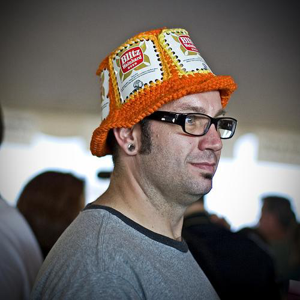


--- Stage 1: Cosine Similarity (Dual-Encoder) ---
Original caption: 0.5845
Custom caption:   0.6259

--- Stage 2: ITM Match Score (Cross-Attention Re-Ranker) ---
Original caption: 0.9829 (Good match)
Custom caption:   0.9922 (Good match)


In [ ]:
# Pick an example image from the test set
example_idx = 0
example_image = test_data[example_idx]["image"].convert("RGB")
original_caption = test_data[example_idx]["caption"]

# Assign your own caption here:
custom_caption = "A man is wearing an interesting hat."

print(f"Original caption: {original_caption}")
print(f"Custom caption:   {custom_caption}")

display(example_image.resize((300, 300)))

model.eval()
with torch.no_grad():
    image_enc = image_processor(images=[example_image, example_image], return_tensors="pt")
    text_enc = tokenizer(
        [original_caption, custom_caption],
        padding="max_length", truncation=True, max_length=64, return_tensors="pt"
    )

    image_emb, image_tokens = model.encode_image(image_enc["pixel_values"].to(device))
    text_emb, text_tokens = model.encode_text(text_enc["input_ids"].to(device), text_enc["attention_mask"].to(device))

    cosine_scores = F.cosine_similarity(image_emb, text_emb)
    itm_logits = model.compute_itm(text_tokens, image_tokens)
    itm_scores = torch.sigmoid(itm_logits).cpu()

print(f"\n--- Stage 1: Cosine Similarity (Dual-Encoder) ---")
print(f"Original caption: {cosine_scores[0].item():.4f}")
print(f"Custom caption:   {cosine_scores[1].item():.4f}")

print(f"\n--- Stage 2: ITM Match Score (Cross-Attention Re-Ranker) ---")
print(f"Original caption: {itm_scores[0].item():.4f} ({'Good match' if itm_scores[0] > 0.5 else 'Poor match'})")
print(f"Custom caption:   {itm_scores[1].item():.4f} ({'Good match' if itm_scores[1] > 0.5 else 'Poor match'})")

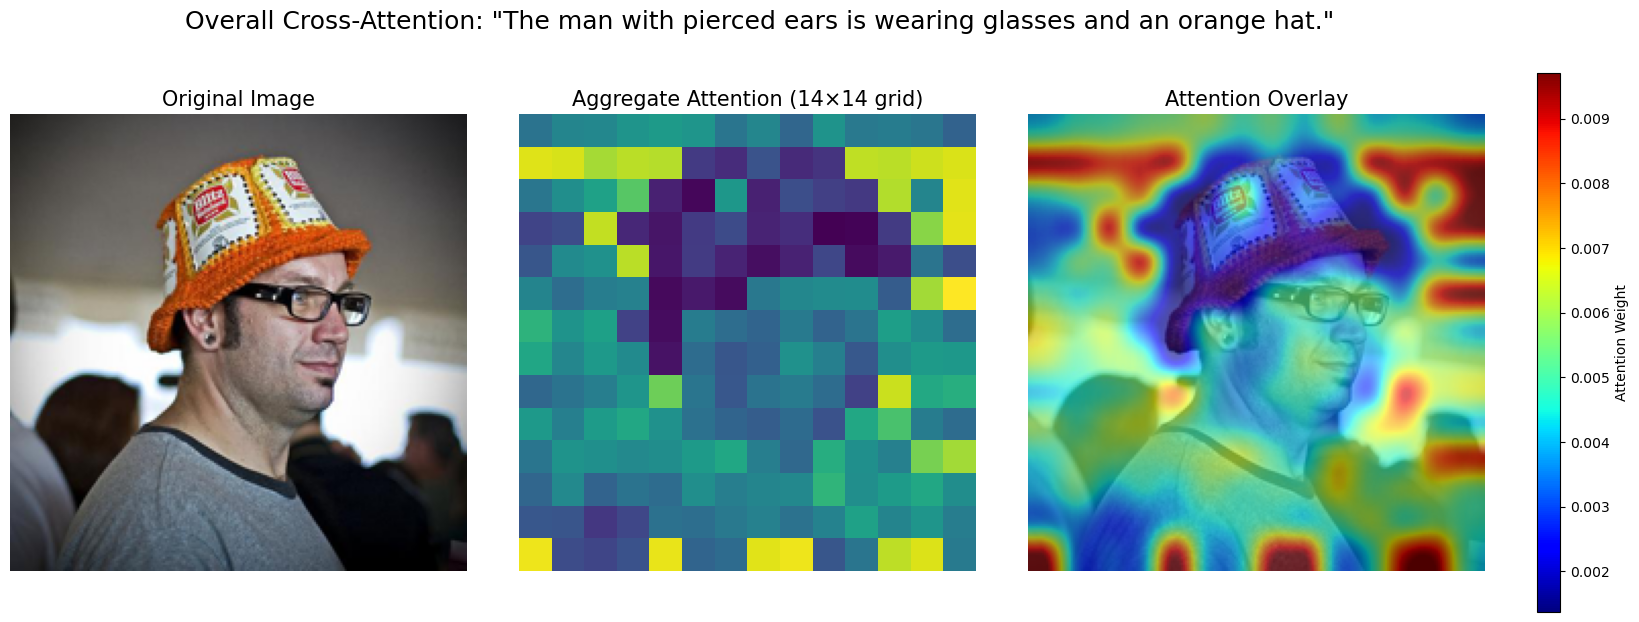

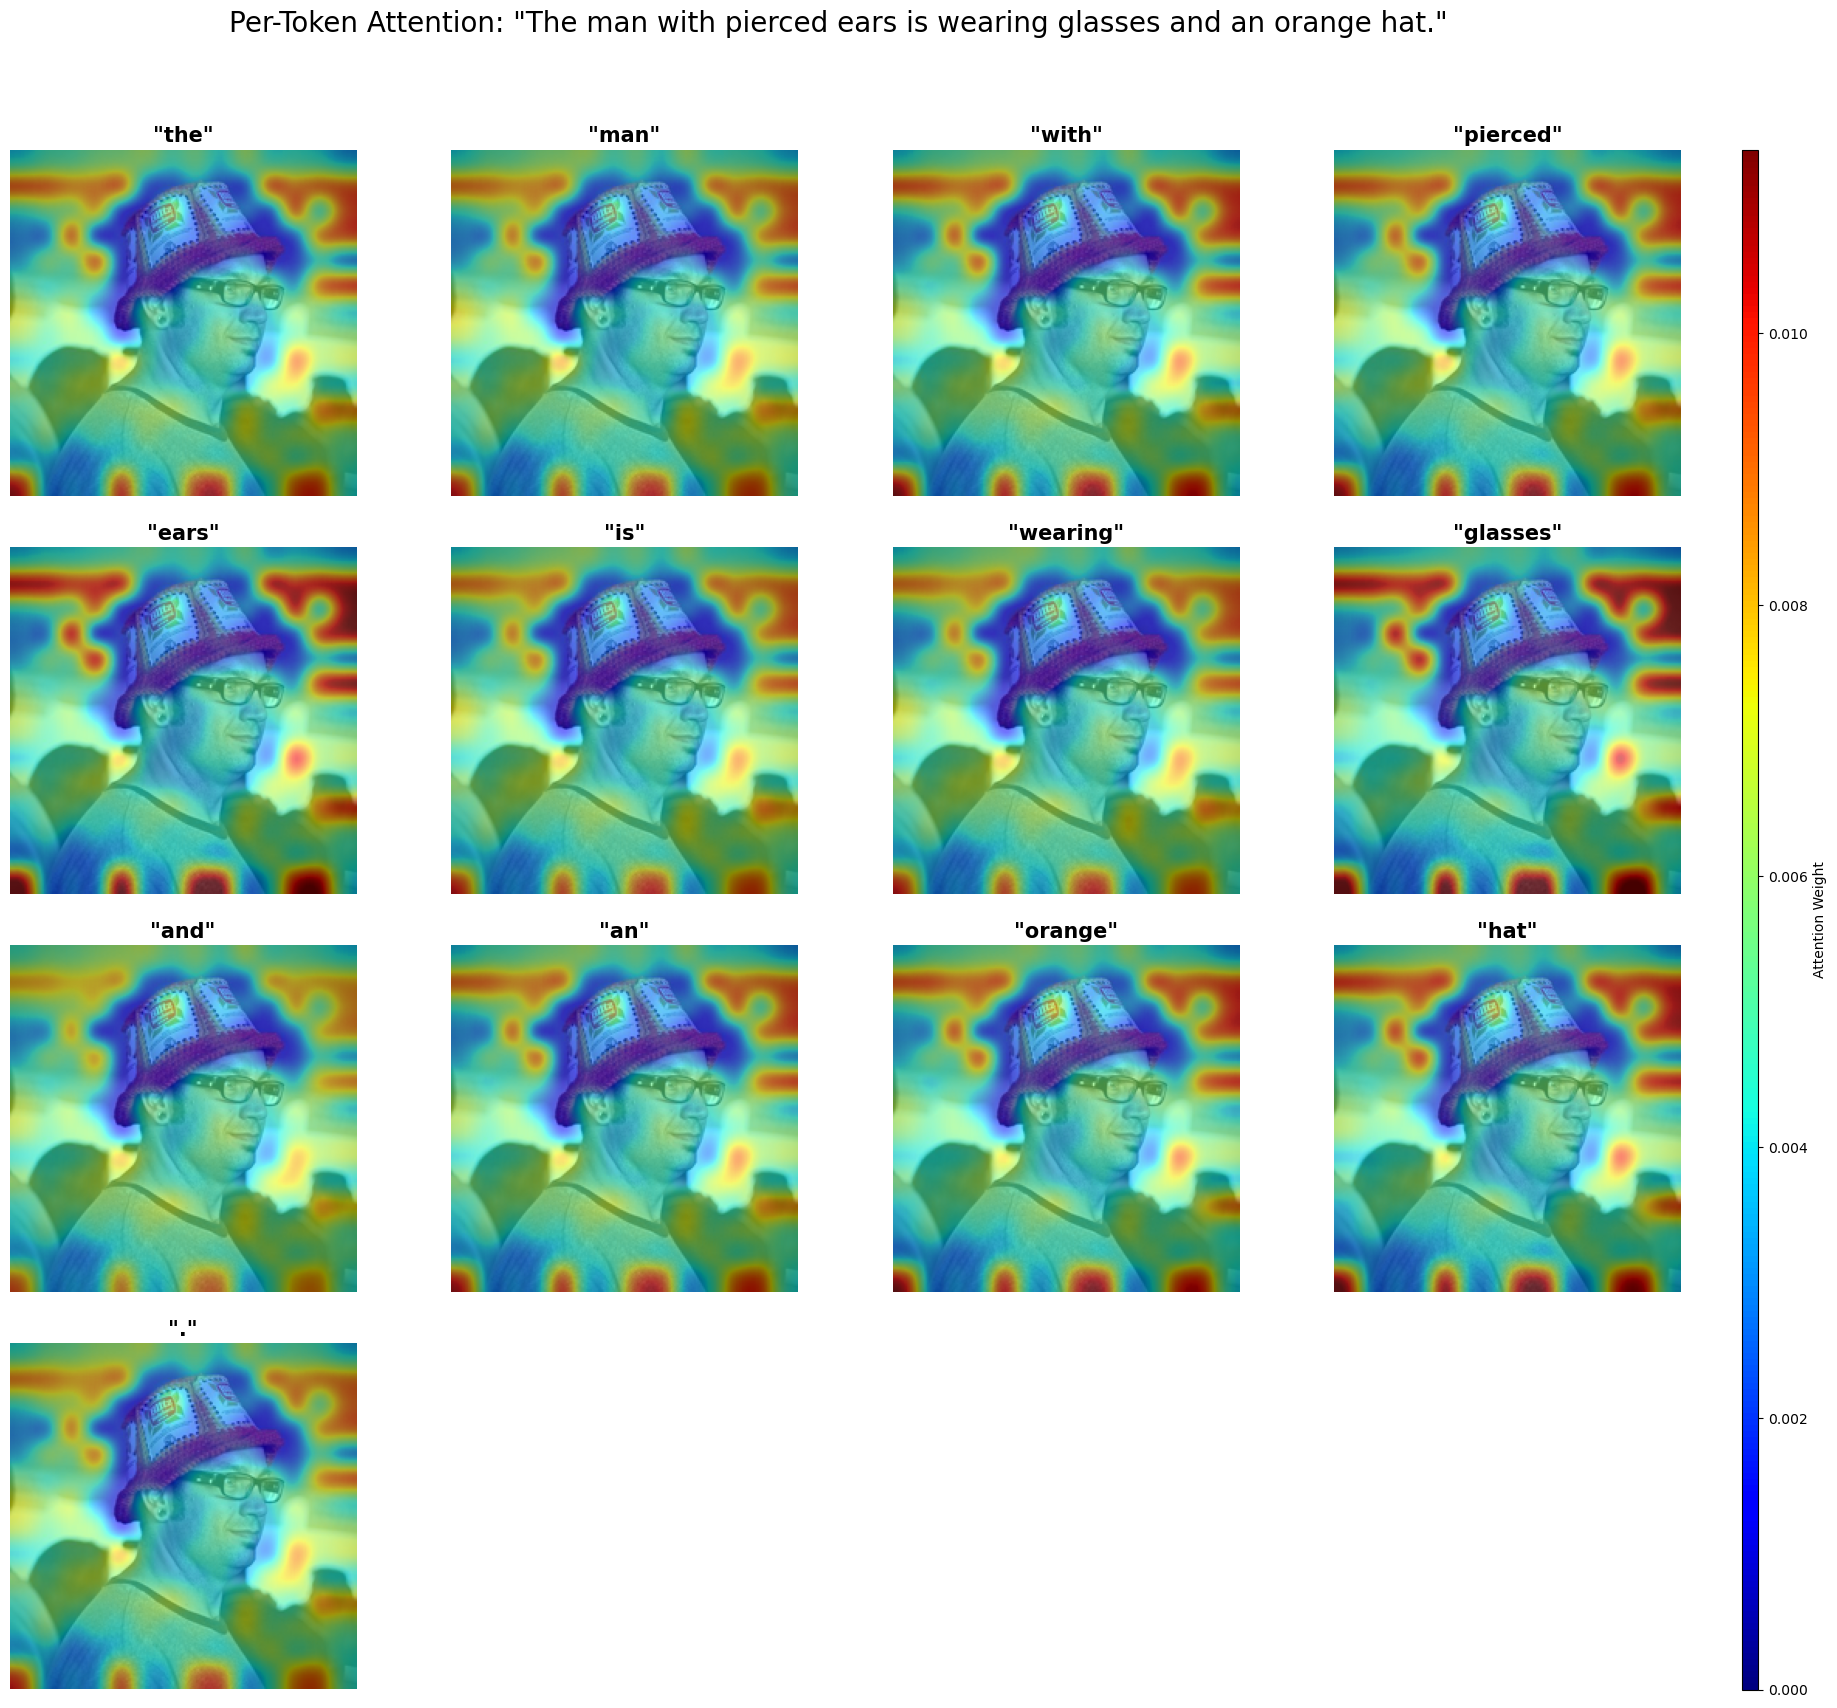

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
import matplotlib.cm as cm

model.eval()

demo_idx = 0
demo_image = test_data[demo_idx]["image"].convert("RGB")
demo_caption = test_data[demo_idx]["caption"]

with torch.no_grad():
    img_enc = image_processor(images=demo_image, return_tensors="pt")
    txt_enc = tokenizer(demo_caption, padding="max_length", truncation=True,
                        max_length=64, return_tensors="pt")

    _, img_tok = model.encode_image(img_enc["pixel_values"].to(device))   # (1, 197, D)
    _, txt_tok = model.encode_text(txt_enc["input_ids"].to(device),
                                   txt_enc["attention_mask"].to(device))  # (1, T, D)

    # Extract attention weights from the LAST text->image cross-attention layer.
    # We run a single forward through that layer to capture attn_weights.
    last_t2i_layer = model.reranker.t2i_layers[-1]
    q_norm = last_t2i_layer.norm_q(txt_tok)
    kv_norm = last_t2i_layer.norm_kv(img_tok)
    _, attn_weights = last_t2i_layer.cross_attn(q_norm, kv_norm, kv_norm)
    # attn_weights shape: (B, T, P) — averaged over heads by nn.MultiheadAttention
    attn = attn_weights.cpu().squeeze(0)  # (T, 197)

# Trim to real text tokens (drop [PAD])
token_ids = txt_enc["input_ids"].squeeze().tolist()
tokens = tokenizer.convert_ids_to_tokens(token_ids)
real_len = tokens.index("[PAD]") if "[PAD]" in tokens else len(tokens)
tokens = tokens[:real_len]
attn_map = attn[:real_len].numpy()        # (real_len, 197)
spatial_attn = attn_map[:, 1:]            # drop ViT [CLS] -> (real_len, 196)

# ── Plot 1: Aggregate attention — what the whole caption looks at ─────────
agg_attn = spatial_attn.mean(axis=0).reshape(14, 14)

fig = plt.figure(figsize=(20, 7))
gs = gridspec.GridSpec(1, 4, width_ratios=[1, 1, 1, 0.05], wspace=0.15)

ax0 = fig.add_subplot(gs[0])
ax0.imshow(demo_image.resize((224, 224)))
ax0.set_title("Original Image", fontsize=15)
ax0.axis("off")

ax1 = fig.add_subplot(gs[1])
ax1.imshow(agg_attn, cmap="viridis")
ax1.set_title("Aggregate Attention (14x14 grid)", fontsize=15)
ax1.axis("off")

ax2 = fig.add_subplot(gs[2])
ax2.imshow(demo_image.resize((224, 224)))
agg_norm = Normalize(vmin=agg_attn.min(), vmax=agg_attn.max())
agg_resized = np.array(Image.fromarray(
    (agg_norm(agg_attn) * 255).astype(np.uint8)).resize((224, 224)))
overlay_im = ax2.imshow(agg_resized, alpha=0.6, cmap="jet",
                        norm=Normalize(vmin=0, vmax=255))
ax2.set_title("Attention Overlay", fontsize=15)
ax2.axis("off")

cax = fig.add_subplot(gs[3])
sm = cm.ScalarMappable(cmap="jet", norm=agg_norm)
sm.set_array([])
fig.colorbar(sm, cax=cax, label="Attention Weight")

fig.suptitle(f'Overall Cross-Attention: "{demo_caption}"', fontsize=18, y=0.97)
plt.show()

# ── Plot 2: Per-token spatial attention overlaid on the image ─────────────
content_tokens = [(i, t) for i, t in enumerate(tokens) if t not in ("[CLS]", "[SEP]")]
n_show = min(len(content_tokens), 20)
ncols = min(n_show, 4)
nrows = (n_show + ncols - 1) // ncols

all_maxes = [spatial_attn[ti].max() for ti, _ in content_tokens[:n_show]]
global_max = max(all_maxes)
norm = Normalize(vmin=0, vmax=global_max)

fig = plt.figure(figsize=(5.5 * ncols + 1, 5 * nrows))
gs = gridspec.GridSpec(nrows, ncols + 1, width_ratios=[1] * ncols + [0.04], wspace=0.08, hspace=0.15)

for ax_i, (tok_i, tok_str) in enumerate(content_tokens[:n_show]):
    row, col = divmod(ax_i, ncols)
    ax = fig.add_subplot(gs[row, col])
    patch_attn = spatial_attn[tok_i].reshape(14, 14)
    ax.imshow(demo_image.resize((224, 224)))
    overlay = np.array(Image.fromarray(
        (norm(patch_attn) * 255).astype(np.uint8)).resize((224, 224)))
    ax.imshow(overlay, alpha=0.55, cmap="jet", norm=Normalize(vmin=0, vmax=255))
    ax.set_title(f'"{tok_str}"', fontsize=15, fontweight="bold")
    ax.axis("off")

for ax_i in range(n_show, nrows * ncols):
    row, col = divmod(ax_i, ncols)
    ax = fig.add_subplot(gs[row, col])
    ax.axis("off")

cax = fig.add_subplot(gs[:, -1])
sm = cm.ScalarMappable(cmap="jet", norm=norm)
sm.set_array([])
fig.colorbar(sm, cax=cax, label="Attention Weight")

fig.suptitle(f'Per-Token Attention: "{demo_caption}"', fontsize=20, y=0.95)
plt.show()